In [1]:
import warnings
warnings.filterwarnings('ignore')

import pickle, os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
from folium import plugins

OUTPUT_DIR = '../output'
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Load data dari Tahap 3 ───────────────────────────────────
with open(f'{OUTPUT_DIR}/tahap3_clustering.pkl', 'rb') as f:
    d = pickle.load(f)

BEST_DATASET    = d['BEST_DATASET']
BEST_K          = d['BEST_K']
BEST_SIL        = d['BEST_SIL']
BEST_LABELS     = d['BEST_LABELS']
CLUSTER_COLORS  = d['CLUSTER_COLORS']
meta_linear     = d['meta_linear']
meta_poly       = d['meta_poly']
X_linear        = d['X_linear']
X_poly          = d['X_poly']
df_hasil        = d['df_hasil']

meta_best = meta_linear if 'Linear' in BEST_DATASET else meta_poly
X_raw     = X_linear    if 'Linear' in BEST_DATASET else X_poly

print(f'Data Tahap 3 berhasil dimuat.')
print(f'  Konfigurasi terbaik: {BEST_DATASET}, k={BEST_K}, sil={BEST_SIL:.4f}')
print(f'  Jumlah wilayah     : {len(meta_best)}')

Data Tahap 3 berhasil dimuat.
  Konfigurasi terbaik: Poly-204, k=2, sil=0.5375
  Jumlah wilayah     : 37


In [2]:
# ── Koordinat hardcoded (terverifikasi manual) ────────────────
KOORDINAT_DB = {
    'Baron Nganjuk'              : (-7.5083,  111.9167),
    'Nunukan'                    : ( 4.1333,  117.6667),
    'Sreseh, Sampang'            : (-7.1833,  113.2167),
    'Manyar, Gresik'             : (-7.1500,  112.6500),
    'Kamal, Bangkalan'           : (-7.1833,  112.7833),
    'Kedungpring Lamongan'       : (-7.3500,  112.2167),
    'Gresik Kota, Gresik'        : (-7.1556,  112.6527),
    'Waru, Pamekasan'            : (-7.1667,  113.4833),
    'Paciran, Lamongan'          : (-6.8667,  112.3333),
    'Kertosono, Nganjuk'         : (-7.5833,  112.1000),
}

CACHE_FILE = f'{OUTPUT_DIR}/koordinat_cache.json'

# Load cache yang sudah ada
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE) as f:
        koordinat_cache = json.load(f)
    print(f'Cache dimuat: {len(koordinat_cache)} koordinat')
else:
    koordinat_cache = {}

def get_koordinat(daerah: str):
    """Cari koordinat dengan prioritas: hardcoded → cache → Nominatim → fallback."""
    if daerah in koordinat_cache:
        return tuple(koordinat_cache[daerah])
    # Cek hardcoded
    for key, coord in KOORDINAT_DB.items():
        if key.lower() in daerah.lower() or daerah.lower() in key.lower():
            return coord
    # Coba Nominatim
    try:
        from geopy.geocoders import Nominatim
        from geopy.extra.rate_limiter import RateLimiter
        geo = Nominatim(user_agent='psd_cluster_2026')
        geocode = RateLimiter(geo.geocode, min_delay_seconds=1)
        loc = geocode(daerah + ', Indonesia')
        if loc:
            print(f'  Nominatim: {daerah} → ({loc.latitude:.4f}, {loc.longitude:.4f})')
            return (loc.latitude, loc.longitude)
    except Exception as e:
        print(f'  Nominatim gagal ({daerah}): {e}')
    # Fallback: Jawa Timur dengan seed acak dari nama
    rng = np.random.default_rng(abs(hash(daerah)) % 2**32)
    return (-7.5 + rng.uniform(-1.5, 1.5), 112.7 + rng.uniform(-3, 3))

# Geocode semua wilayah
print('\nMengambil koordinat semua wilayah...')
for daerah in meta_best['daerah']:
    if daerah not in koordinat_cache:
        lat, lon = get_koordinat(daerah)
        koordinat_cache[daerah] = [lat, lon]
        time.sleep(0.3)

# Simpan cache
with open(CACHE_FILE, 'w', encoding='utf-8') as f:
    json.dump(koordinat_cache, f, indent=2, ensure_ascii=False)
print(f'\nTotal koordinat: {len(koordinat_cache)} wilayah → disimpan ke cache')

Cache dimuat: 35 koordinat

Mengambil koordinat semua wilayah...

Total koordinat: 35 wilayah → disimpan ke cache


In [3]:
# ── Gabungkan label cluster + koordinat ───────────────────────
df_map = meta_best.copy().reset_index(drop=True)
df_map['cluster'] = BEST_LABELS
df_map['lat'] = df_map['daerah'].map(lambda d: koordinat_cache.get(d, [-7.5, 112.7])[0])
df_map['lon'] = df_map['daerah'].map(lambda d: koordinat_cache.get(d, [-7.5, 112.7])[1])

# Tambahkan statistik polutan utama (NO2, SO2, CO mean)
for pol in ['no2', 'so2', 'co']:
    col_mean = f'{pol}_calc_mean'
    if col_mean in X_raw.columns:
        df_map[f'{pol}_mean'] = X_raw[col_mean].values
    else:
        df_map[f'{pol}_mean'] = np.nan

print('DataFrame peta (semua 37 wilayah):')
print(df_map[['daerah','cluster','lat','lon','no2_mean','so2_mean','co_mean']].to_string())

DataFrame peta (semua 37 wilayah):
                           daerah  cluster       lat         lon  no2_mean  so2_mean   co_mean
0                   Baron Nganjuk        0 -7.508300  111.916700  0.000028  0.000072  0.030248
1                         Nunukan        0  4.133300  117.666700  0.000007 -0.000005  0.027691
2                 Sreseh, Sampang        0 -7.183300  113.216700  0.000027  0.000007  0.029516
3                  Manyar, Gresik        0 -7.150000  112.650000  0.000071  0.000161  0.028816
4                Kamal, Bangkalan        0 -7.183300  112.783300  0.000083  0.000140  0.027027
5            Kedungpring Lamongan        0 -7.350000  112.216700  0.000030  0.000067  0.029689
6             Gresik Kota, Gresik        0 -7.155600  112.652700  0.000064  0.000183  0.028956
7                 Waru, Pamekasan        0 -7.166700  113.483300  0.000015 -0.000035  0.027199
8               Paciran, Lamongan        0 -6.866700  112.333300  0.000029  0.000030  0.029583
9              

In [4]:
# ── Buat peta Folium ──────────────────────────────────────────
# CATATAN: tile CARTO ('CartoDB positron' / 'CartoDB dark_matter') sekarang wajib API key,
# tanpa key peta menampilkan watermark "API KEY REQUIRED". Karena itu basemap default diganti
# ke provider yang tidak memerlukan key (OpenStreetMap dan Esri).
m = folium.Map(
    location=[-2.5, 118.0],   # Pusat Indonesia
    zoom_start=5,
    tiles=None,               # basemap ditambahkan manual di bawah
    control_scale=True
)

folium.TileLayer('OpenStreetMap', name='OpenStreetMap (default)', show=True).add_to(m)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri',
    name='Esri Street Map', show=False
).add_to(m)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri &mdash; Source: Esri, Maxar, Earthstar Geographics',
    name='Citra Satelit (Esri)', show=False
).add_to(m)

# OPSIONAL: aktifkan basemap CARTO jika Anda punya API key gratis (carto.com/basemaps/apikey).
# Simpan key di environment variable CARTO_API_KEY, jangan ditulis langsung di notebook.
CARTO_KEY = os.environ.get('CARTO_API_KEY', '')
if CARTO_KEY:
    carto_attr = ('&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a>, '
                  '&copy; <a href="https://carto.com/attributions">CARTO</a>')
    for estilo, nama in [('light_all', 'CARTO Light'), ('dark_all', 'CARTO Dark')]:
        folium.TileLayer(
            tiles=f'https://basemaps.cartocdn.com/rastertiles/{estilo}/{{z}}/{{x}}/{{y}}.png?key={CARTO_KEY}',
            attr=carto_attr, name=nama, show=False
        ).add_to(m)

# Buat FeatureGroup per cluster
fg_clusters = []
for c in range(BEST_K):
    fg = folium.FeatureGroup(name=f'Cluster {c}', show=True)
    fg_clusters.append(fg)
    m.add_child(fg)

# Tambahkan marker
for _, row in df_map.iterrows():
    c   = int(row['cluster'])
    col = CLUSTER_COLORS[c % len(CLUSTER_COLORS)]

    # Popup HTML detail
    no2_txt = f"{row.get('no2_mean', float('nan')):.4f}" if pd.notna(row.get('no2_mean')) else 'N/A'
    so2_txt = f"{row.get('so2_mean', float('nan')):.4f}" if pd.notna(row.get('so2_mean')) else 'N/A'
    co_txt  = f"{row.get('co_mean',  float('nan')):.4f}" if pd.notna(row.get('co_mean'))  else 'N/A'

    popup_html = f"""
    <div style="font-family:'Segoe UI',Arial,sans-serif; min-width:220px; max-width:280px;">
      <div style="background:{col};color:white;padding:8px 12px;border-radius:6px 6px 0 0;">
        <b style="font-size:14px;">Cluster {c}</b>
      </div>
      <div style="padding:10px 12px;border:1px solid #eee;border-top:none;border-radius:0 0 6px 6px;">
        <table style="width:100%;border-collapse:collapse;font-size:12px;">
          <tr><td style="color:#777;padding:2px 0">Daerah</td>
              <td><b>{row['daerah']}</b></td></tr>
          <tr><td style="color:#777;padding:2px 0">Nama</td>
              <td>{row['nama']}</td></tr>
          <tr><td style="color:#777;padding:2px 0">Koordinat</td>
              <td>{row['lat']:.4f}, {row['lon']:.4f}</td></tr>
          <tr><td colspan=2><hr style="margin:6px 0"></td></tr>
          <tr><td style="color:#1565C0;padding:2px 0">NO₂ mean</td>
              <td><b>{no2_txt}</b></td></tr>
          <tr><td style="color:#B71C1C;padding:2px 0">SO₂ mean</td>
              <td><b>{so2_txt}</b></td></tr>
          <tr><td style="color:#1B5E20;padding:2px 0">CO mean</td>
              <td><b>{co_txt}</b></td></tr>
          <tr><td colspan=2><hr style="margin:6px 0"></td></tr>
          <tr><td style="color:#777">Dataset</td>
              <td>{BEST_DATASET}</td></tr>
          <tr><td style="color:#777">Silhouette</td>
              <td>{BEST_SIL:.4f}</td></tr>
        </table>
      </div>
    </div>
    """

    # Circle marker
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=14, color=col, fill=True,
        fill_color=col, fill_opacity=0.75, weight=2.5,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"Cluster {c}: {row['daerah']}"
    ).add_to(fg_clusters[c])

    # Label cluster di tengah marker
    folium.Marker(
        location=[row['lat'], row['lon']],
        icon=folium.DivIcon(
            html=(f'<div style="font-size:9px;font-weight:bold;color:white;'
                  f'background:{col};border-radius:50%;width:22px;height:22px;'
                  f'display:flex;align-items:center;justify-content:center;'
                  f'box-shadow:0 2px 4px rgba(0,0,0,0.4);">C{c}</div>'),
            icon_size=(22, 22), icon_anchor=(11, 11)
        ),
        tooltip=row['daerah']
    ).add_to(fg_clusters[c])

print(f'Marker berhasil ditambahkan untuk {len(df_map)} wilayah.')

Marker berhasil ditambahkan untuk 37 wilayah.


In [5]:
# ── Legenda HTML ──────────────────────────────────────────────
uniq, cnts = np.unique(BEST_LABELS, return_counts=True)

legend_items = ''.join([
    f'<div style="display:flex;align-items:center;margin:4px 0;">'
    f'<div style="width:16px;height:16px;border-radius:50%;background:{CLUSTER_COLORS[c]};'
    f'margin-right:8px;flex-shrink:0;"></div>'
    f'<span>Cluster {c} — {n} wilayah</span></div>'
    for c, n in zip(uniq, cnts)
])

legend_html = f"""
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
            background:white;padding:16px 20px;border-radius:10px;
            box-shadow:0 4px 15px rgba(0,0,0,0.2);
            font-family:'Segoe UI',Arial,sans-serif;min-width:200px;">
  <div style="font-size:14px;font-weight:bold;margin-bottom:4px;">Segmentasi Cluster</div>
  <div style="font-size:11px;color:#777;margin-bottom:10px;">
    Dataset: {BEST_DATASET} | k={BEST_K} | Sil={BEST_SIL:.3f}
  </div>
  <hr style="margin:0 0 10px;border-color:#eee;">
  {legend_items}
  <hr style="margin:10px 0 6px;border-color:#eee;">
  <div style="font-size:10px;color:#aaa;">Klik marker untuk detail</div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Layer control
folium.LayerControl(collapsed=False, position='topright').add_to(m)

# Minimap
try:
    minimap = plugins.MiniMap(toggle_display=True, tile_layer='OpenStreetMap')
    m.add_child(minimap)
except Exception:
    pass

# Simpan peta
map_path = f'{OUTPUT_DIR}/peta_clustering_interaktif.html'
m.save(map_path)
print(f'Peta interaktif disimpan:')
print(f'  {os.path.abspath(map_path)}')
print(f'  Ukuran: {os.path.getsize(map_path)/1024:.0f} KB')

# Tampilkan di notebook
m

Peta interaktif disimpan:
  C:\Users\OKAN\OneDrive\Dokumen\PSD\materi\Clustering_Segmentasi\output\peta_clustering_interaktif.html
  Ukuran: 142 KB


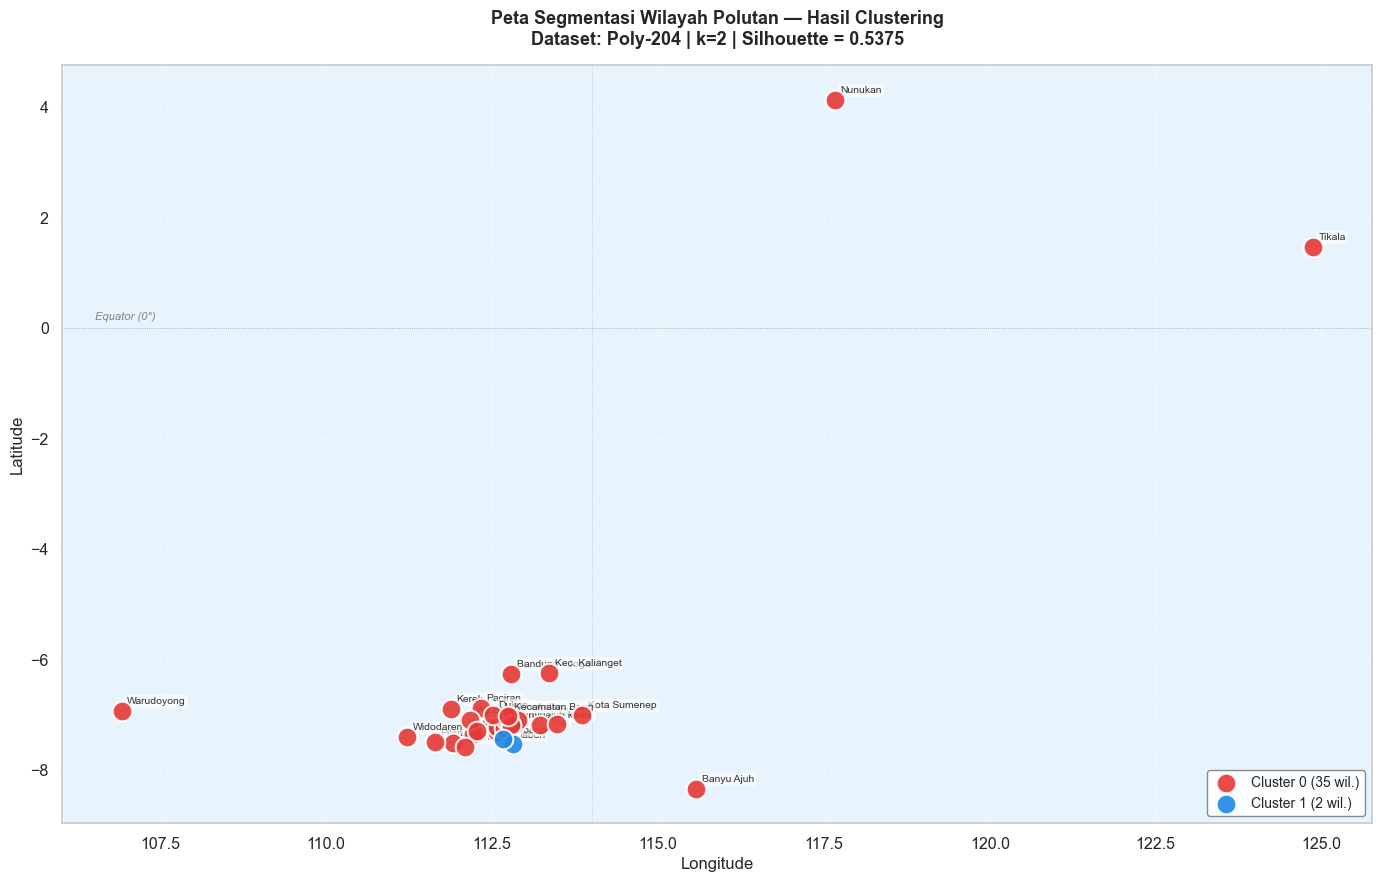

Peta statis disimpan: output/12_peta_statis.png


In [6]:
# ── Peta statis scatter ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 9))

for c in range(BEST_K):
    mask = df_map['cluster'] == c
    sub  = df_map[mask]
    ax.scatter(sub['lon'], sub['lat'],
               s=200, color=CLUSTER_COLORS[c],
               edgecolors='white', linewidth=1.5,
               label=f'Cluster {c} ({mask.sum()} wil.)',
               alpha=0.9, zorder=4)
    for _, row in sub.iterrows():
        ax.annotate(
            row['daerah'].split(',')[0][:14],
            xy=(row['lon'], row['lat']),
            xytext=(4, 5), textcoords='offset points',
            fontsize=7.5, color='#333',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6, linewidth=0)
        )

# Garis grid
ax.set_facecolor('#E8F4FD')
ax.grid(True, linestyle='--', alpha=0.4, color='white')

# Garis batas
ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(114, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(f'Peta Segmentasi Wilayah Polutan — Hasil Clustering\n'
             f'Dataset: {BEST_DATASET} | k={BEST_K} | Silhouette = {BEST_SIL:.4f}',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9,
          edgecolor='gray', fancybox=True)

# Anotasi equator
ax.text(ax.get_xlim()[0]+0.5, 0.15, 'Equator (0°)',
        fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_peta_statis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Peta statis disimpan: output/12_peta_statis.png')

In [7]:
# ── Cetak ringkasan lengkap ───────────────────────────────────
separator = '=' * 65
print(separator)
print(' RINGKASAN LENGKAP ANALISIS CLUSTERING SEGMENTASI POLUTAN')
print(separator)

print('\n[TAHAP 1] DATA & EDA')
print(f'  Sumber   : MySQL — basisda1_PSD-A-Interpolasi')
print(f'  Tabel    : ekstraksi_fitur_linear + ekstraksi_fitur_polynomial')
print(f'  Ukuran   : 37 wilayah × 204 fitur (68 per polutan)')

print('\n[TAHAP 2] REDUKSI DIMENSI (PCA)')
print(f'  Standardisasi : StandardScaler (mean=0, std=1)')
print(f'  PCA Tahap 1   : 204 → 74 komponen')
print(f'  PCA Tahap 2   : 74  → 37 komponen')
print(f'  Total varian  : tergantung dataset (lihat notebook Tahap 2)')

print('\n[TAHAP 3] EKSPERIMEN CLUSTERING')
print(f'  Algoritma     : K-Means (k-means++, n_init=20)')
print(f'  Variasi       : 6 dataset × k=2..10 = 54 eksperimen')
print(f'  Evaluasi      : Silhouette Coefficient')
print(f'  Konfigurasi   : {BEST_DATASET}, k={BEST_K}')
print(f'  Silhouette    : {BEST_SIL:.4f}')

print('\n[TAHAP 4] VISUALISASI PETA')
print(f'  Geocoding     : Nominatim (OpenStreetMap) + hardcoded')
print(f'  Peta interaktif : output/peta_clustering_interaktif.html')
print(f'  Peta statis     : output/12_peta_statis.png')

print('\nDISTRIBUSI WILAYAH PER CLUSTER:')
print('-' * 65)
for c in range(BEST_K):
    mask = df_map['cluster'] == c
    wils = df_map[mask]['daerah'].tolist()
    print(f'\nCluster {c} ({len(wils)} wilayah) ─ warna: {CLUSTER_COLORS[c]}')
    for w in wils:
        print(f'   • {w}')

print('\n' + separator)
print(' OUTPUT FILES (folder output/)')
print(separator)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath)
    print(f'  {fname:<45} {size/1024:6.1f} KB')
print('\n[SELESAI]')

 RINGKASAN LENGKAP ANALISIS CLUSTERING SEGMENTASI POLUTAN

[TAHAP 1] DATA & EDA
  Sumber   : MySQL — basisda1_PSD-A-Interpolasi
  Tabel    : ekstraksi_fitur_linear + ekstraksi_fitur_polynomial
  Ukuran   : 37 wilayah × 204 fitur (68 per polutan)

[TAHAP 2] REDUKSI DIMENSI (PCA)
  Standardisasi : StandardScaler (mean=0, std=1)
  PCA Tahap 1   : 204 → 74 komponen
  PCA Tahap 2   : 74  → 37 komponen
  Total varian  : tergantung dataset (lihat notebook Tahap 2)

[TAHAP 3] EKSPERIMEN CLUSTERING
  Algoritma     : K-Means (k-means++, n_init=20)
  Variasi       : 6 dataset × k=2..10 = 54 eksperimen
  Evaluasi      : Silhouette Coefficient
  Konfigurasi   : Poly-204, k=2
  Silhouette    : 0.5375

[TAHAP 4] VISUALISASI PETA
  Geocoding     : Nominatim (OpenStreetMap) + hardcoded
  Peta interaktif : output/peta_clustering_interaktif.html
  Peta statis     : output/12_peta_statis.png

DISTRIBUSI WILAYAH PER CLUSTER:
-----------------------------------------------------------------

Cluster 0 (35 w